<a href="https://colab.research.google.com/github/gar-nov/tirocinio/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISI ESPLORATIVA DEI DATI (EDA)
Dopo aver effettuato la pulizia dei dati sul dataset, passiamo all'analisi esplorativa dei dati.
i principali obbiettivi:
- la verifica della qualità del dataset dopo la pulizia
- l'analisi della distribuzione tra classi
- esaminare la frequenza dei diversi tipi di attacco

importazione librerie e caricamento dataset filtrato per l'EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')






Mounted at /content/drive


In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/veremi_clean.csv')

# Controllo iniziale
print("Dimensioni del dataset:", data.shape)
data.head()


Dimensioni del dataset: (4845815, 11)


,rcvTime,pos_0,pos_1,spd_0,spd_1,acl_0,acl_1,hed_0,hed_1,attack,attack_type
0,50831.914564,1288.736480,1059.729123,-16.287118,-2.921455,-0.055350,-0.009209,-0.998074,-0.062034,0,constposoffset
1,26663.698218,498.583238,303.468778,13.394928,4.750152,-0.562873,-0.199565,0.950863,0.309613,0,constposoffset
2,52161.314993,266.572055,41.134647,-0.531761,5.146397,-0.274390,2.655753,-0.095646,0.995415,0,constposoffset
3,27659.392320,365.106961,257.518958,14.903867,5.368904,-0.080198,-0.028698,0.954075,0.299568,1,randomposoffset
4,25623.210073,347.726613,483.105599,-9.744141,-7.657281,0.310752,0.244477,-0.799141,-0.601144,0,eventualstop


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Creo un campione dal dataset solo per i grafici
N = 300_000
df_plot = data.sample(n=min(N, len(data)), random_state=42)

print("Dimensioni del sample per i grafici:", df_plot.shape)


Dimensioni del sample per i grafici: (300000, 11)


### Distribuzione messaggi benigni vs messaggi malevoli

Dal grafico vediamo che la distribuzione non è perfettamente bilanciata

/tmp/ipython-input-273454440.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="attack", data=df_plot, palette="Set2")


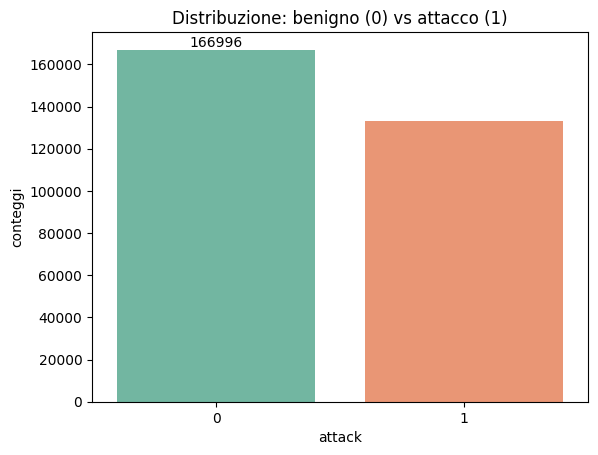

Percentuali:
 attack
0    55.64
1    44.36
Name: proportion, dtype: float64


In [ ]:
ax = sns.countplot(x="attack", data=df_plot, palette="Set2")
ax.bar_label(ax.containers[0])  # scrive i numeri sopra le barre
plt.title("Distribuzione: benigno (0) vs attacco (1)")
plt.xlabel("attack")
plt.ylabel("conteggi")
plt.show()

# Percentuali
print("Percentuali:\n", data["attack"].value_counts(normalize=True).mul(100).round(2))


### Distribuzione dei tipi di attacco

Il dataset include cinque scenari di attacco principali (constpos, constposoffset, randompos, randomposoffset, eventualstop),
oltre ai messaggi benigni.  

Dal grafico e dalla tabella si osserva che la distribuzione è **equilibrata tra i cinque tipi di attacco**: ciascun tipo ha un numero simile di occorrenze.  
Questo significa che i modelli potranno imparare a distinguere tra attacchi diversi senza che uno sia sovrarappresentato rispetto agli altri.


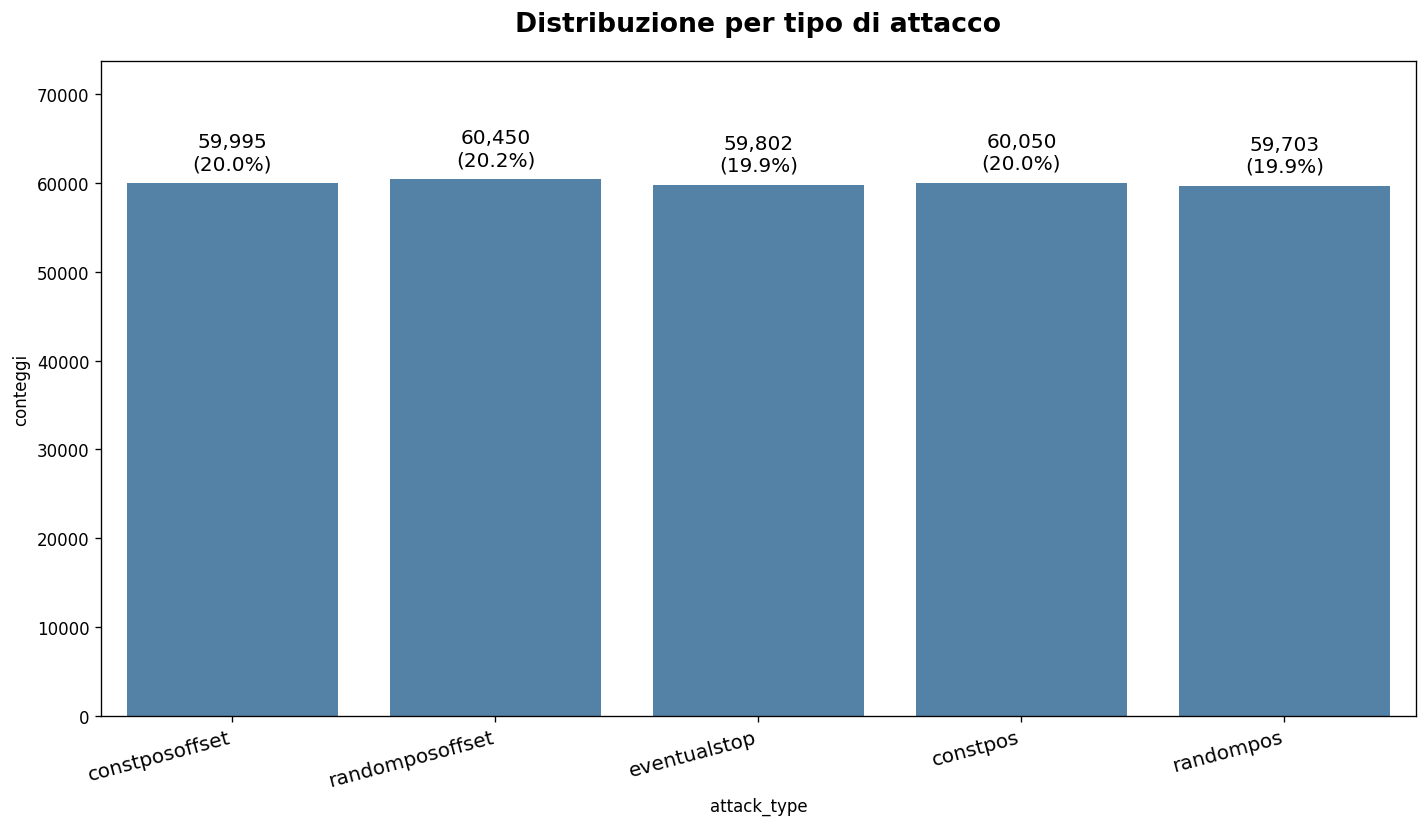

In [ ]:
order = data["attack_type"].value_counts().index

plt.figure(figsize=(12,7), dpi=120)
ax = sns.countplot(x='attack_type', data=df_plot, order=order, color="steelblue")
ax.set_title("Distribuzione per tipo di attacco", pad=18, fontsize=16, weight='bold')
ax.set_xlabel("attack_type"); ax.set_ylabel("conteggi")

# più spazio sopra le barre
ymax = max(p.get_height() for p in ax.patches)
ax.set_ylim(0, ymax * 1.22)

total = len(df_plot)
for p in ax.patches:
    h = p.get_height()
    label = f"{int(h):,}\n({h/total:.1%})"
    ax.annotate(label,
                (p.get_x() + p.get_width()/2., h),
                ha='center', va='bottom', xytext=(0, 6), textcoords='offset points',
                fontsize=12,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))

plt.xticks(rotation=15, ha="right", fontsize=12)
plt.tight_layout()
plt.show()



### Statistiche descrittive delle variabili numeriche

Dalla tabella si osservano alcune caratteristiche importanti del dataset:

- **rcvTime**: il tempo di ricezione dei messaggi varia da circa 25.000 a 54.000 secondi, con una media di ~38.000.  
  È una variabile continua che cresce nel tempo, quindi non porta informazione diretta per la classificazione.

- **pos_0 e pos_1**: rappresentano le coordinate spaziali. I valori si distribuiscono in un range di circa 0–1500,
  che corrisponde all’area simulata del traffico (scenario LuST).  

- **spd_0 e spd_1**: sono le componenti della velocità lungo gli assi. Hanno valori sia positivi che negativi
  (fino a ±18), con media vicina a 0. Questo indica che il dataset contiene movimenti in direzioni opposte
  (coerente con il traffico stradale).

- **acl_0 e acl_1**: accelerazioni lungo i due assi. I valori sono concentrati vicino allo zero con range ±4.5.  
  Questo è plausibile: la maggior parte dei veicoli accelera poco nella maggior parte del tempo.

- **hed_0 e hed_1**: componenti normalizzate del vettore di heading (direzione). Sono comprese tra -1 e 1,
  come ci si aspetta da un coseno/seno di un angolo di direzione.

💡 Queste statistiche confermano che i dati sono già normalizzati/scalati in modo naturale: velocità e accelerazioni
si distribuiscono intorno a zero, mentre heading è limitato a [-1,1]. Prima del training, potrà essere utile
valutare una **scalatura standard (StandardScaler)**, ma i range sono già compatti.


In [ ]:
num_cols = ["rcvTime","pos_0","pos_1","spd_0","spd_1","acl_0","acl_1","hed_0","hed_1"]

# Statistiche descrittive
stats = data[num_cols].describe().T.round(3)
display(stats)


,count,mean,std,min,25%,50%,75%,max
rcvTime,4845815.0,38056.577,12362.361,25208.812,27119.650,28518.939,51911.182,54180.335
pos_0,4845815.0,536.316,416.368,0.002,196.919,276.044,908.100,1502.747
pos_1,4845815.0,667.725,326.805,-7.283,386.984,728.267,916.685,1499.999
spd_0,4845815.0,-0.344,7.025,-18.584,-2.398,0.000,1.882,18.168
spd_1,4845815.0,0.317,7.870,-18.411,-4.255,0.000,4.921,17.940
acl_0,4845815.0,-0.002,0.875,-4.500,-0.155,0.000,0.133,4.504
acl_1,4845815.0,-0.018,1.166,-4.500,-0.208,0.000,0.206,4.505
hed_0,4845815.0,-0.065,0.636,-1.000,-0.623,-0.026,0.142,1.000
hed_1,4845815.0,0.037,0.768,-1.000,-0.837,0.065,0.966,1.000


### Analisi temporale con `rcvTime`

La variabile `rcvTime` indica il tempo della simulazione (secondi dall’inizio).  
Ad esempio, 25.000 secondi ≈ 07:00 del mattino.  

Nel dataset i valori appaiono in blocchi (25k–30k, 50k–54k) perché sono il risultato
di più finestre da 100 secondi ripetute in diversi scenari.  

 `rcvTime` è utile in EDA per mostrare la distribuzione temporale,
ma non verrà incluso come feature nei modelli di classificazione.


### Analisi temporale degli attacchi (`rcvTime`)

Il grafico mostra la distribuzione dei messaggi benigni e malevoli lungo il tempo di simulazione (`rcvTime`).  

Si osservano due blocchi principali di messaggi, che corrispondono a simulazioni diverse.  
All’interno di ciascun blocco, attacchi e messaggi benigni sono distribuiti in modo simile: non ci sono intervalli
in cui compaiono solo attacchi o solo messaggi corretti.  

 Questo conferma che `rcvTime` è utile solo a livello esplorativo per descrivere il dataset,
ma non verrà incluso come feature nel training dei modelli di classificazione.


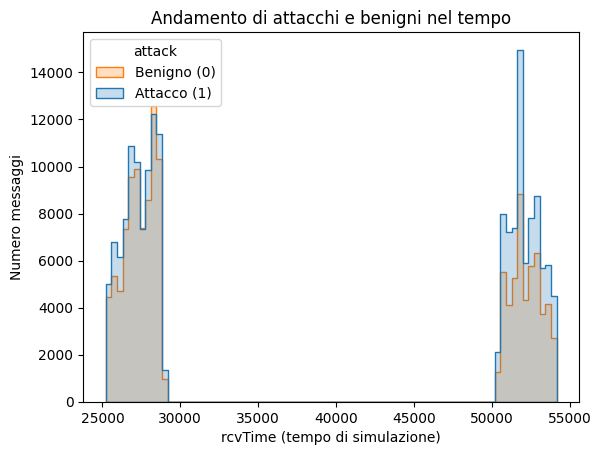

In [ ]:
# Istogramma attacchi vs benigni nel tempo
sns.histplot(data=df_plot, x="rcvTime", hue="attack", bins=80, element="step", stat="count")
plt.title("Andamento di attacchi e benigni nel tempo")
plt.xlabel("rcvTime (tempo di simulazione)")
plt.ylabel("Numero messaggi")
plt.legend(title="attack", labels=["Benigno (0)", "Attacco (1)"])
plt.show()
